<a href="https://colab.research.google.com/github/Minhaz-04/VOIS_Major_Project/blob/main/Major_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seasonal Agriculture Performance Analysis

**Project**: VOIS AICTE Batch 2026-2027 — Major Project

**Dataset**: seasonal_agriculture_performance_dataset.csv (4,000 records, 28 columns)

## Objective
This notebook analyzes how agricultural performance varies across the three growing seasons Kharif, Rabi and Zaid to identify meaningful patterns, relationships and differences in environmental conditions, resource usage, economic outcomes and to support evidence based seasonal planning.

## Analytical Questions
1. Does agricultural performance (yield, profit) differ significantly across seasons?
2. Which environmental and resource factors are associated with these differences?
3. Do seasonal patterns hold consistently across states and crops?
4. What unusual patterns exist between yield and profitability?
5. What does this suggest for seasonal agricultural planning?

# Table of Contents
## 1. Data Loading & Initial Exploration
## 2. Data Cleaning & Preparation
## 3. Season-wise Exploratory Analysis
## 4. Visualizations
## 5. Statistical Testing
## 6. Deeper Relationships (State-level, Efficiency, Anomalies)
## 7. Key Findings & Recommendations
## 8. Conclusion and limitations

## 1. Data Loading & Initial Exploration

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

### 1.2 Load the Dataset

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')

#### Preview: First 5 Rows

In [3]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


#### Preview: Last 5 Rows

In [4]:
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


### 1.3 Dataset Shape and Structure

In [5]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (4000, 28)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### 1.4 Statistical Summary of Numeric Columns

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,186.036000,5.070935,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,60.260583,1.978879,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,40.000000,0.500000,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,143.975000,3.690000,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,186.250000,5.120000,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,227.200000,6.400000,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,400.000000,12.080000,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


### 1.5 Overview of Categorical Columns

In [9]:
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']
for col in categorical_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts())


State — 8 unique values
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District — 10 unique values
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop — 8 unique values
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season — 3 unique values
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method — 4 unique values
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


### 1.6 Check for Missing Values

In [10]:
missing = df.isnull().sum()
print(missing[missing > 0])

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


### 1.7 Check for Duplicate Rows

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 2. Data Cleaning & Preparation

### 2.1 Identify Missing Values

In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing)
print("\nPercent missing:")
print((missing / len(df) * 100).round(2))

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Percent missing:
Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64


Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha have missing values of 1.2%, 1.0% and 0.8% of records respectively a small enough share to impute safely without materially skewing results.

### 2.2 Check Where Missing Values Occur

In [13]:
df[df['Rainfall_mm'].isnull()]['Season'].value_counts()

,count
Season,
Kharif,19
Rabi,18
Zaid,11


In [14]:
df[df['Soil_Moisture_pct'].isnull()]['Season'].value_counts()

,count
Season,
Kharif,18
Rabi,13
Zaid,9


In [15]:
df[df['Yield_Tonnes_Ha'].isnull()]['Season'].value_counts()

,count
Season,
Rabi,20
Kharif,7
Zaid,5


Missing values in all three columns are spread fairly evenly across seasons. Therefore, a group wise median imputation by Season and Crop is appropriate rather than needing a different strategy per season.

### 2.3 Impute Missing Values

In [16]:
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(
        lambda x: x.fillna(x.median())
    )
for col in cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

print(df[cols_to_impute].isnull().sum())

Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


Missing values in Rainfall_mm, Soil_Moisture_pct and Yield_Tonnes_Ha were filled using the median within each Season, Crop group rather than a single overall median to preserve genuine seasonal differences rather than diluting them. After imputation all three columns show 0 remaining missing values.

### 2.4 Check for Duplicate Rows

In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 2.5 Validate Value Ranges

In [18]:
range_checks = {
    'Soil_pH' : (0, 14),
    'Humidity_pct' : (0, 100),
    'Disease_Pest_Risk_pct' : (0, 100),
    'Seed_Quality_Score' : (0, 1),
}

for col, (low, high) in range_checks.items():
  out_of_range = df[(df[col] < low) | (df[col] > high)]
  print(f"{col} : {len(out_of_range)} rows out of expected range [{low}, {high}]")

Soil_pH : 0 rows out of expected range [0, 14]
Humidity_pct : 0 rows out of expected range [0, 100]
Disease_Pest_Risk_pct : 0 rows out of expected range [0, 100]
Seed_Quality_Score : 0 rows out of expected range [0, 1]


Soil_pH, Humidity_pct, Disease_Pest_Risk_pct and Seed_Quality_Score were checked against their expected valid ranges. All values fell within expected bounds confirming no impossible or corrupted entries in these columns.

### 2.6 Check Categorical Value Consistency

In [19]:
for col in ['State', 'Season', 'Crop', 'Irrigation_Method']:
    print(col, ':', sorted(df[col].unique()))

State : ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
Season : ['Kharif', 'Rabi', 'Zaid']
Crop : ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Irrigation_Method : ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


Categorical columns like State, Season, Crop and Irrigation_Method were checked for inconsistent spelling, casing or stray whitespace.

### 2.7 Flag Negative Profit Values

In [20]:
neg_profit = df[df['Profit_INR'] < 0]
print(f"Farms with negative profit: {len(neg_profit)} ({len(neg_profit)/len(df)*100:.1f}%)")
neg_profit.groupby('Season')['Profit_INR'].describe()

Farms with negative profit: 1966 (49.1%)


,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,751.0,-221832.994674,206711.764729,-976860.0,-332225.5,-151976.0,-53567.50,-7.0
Rabi,832.0,-199242.545673,189983.874194,-1019223.0,-293870.0,-141476.0,-48807.25,-188.0
Zaid,383.0,-239759.302872,203032.981468,-965197.0,-351639.0,-184402.0,-73218.50,-17.0


49.1% of farms show negative profit nearly half the dataset. This is treated as a genuine finding rather than a data error and is retained for analysis in later sections. The scale of losses is broadly similar across seasons (mean losses ranging from
roughly ₹1.99 lakh in Rabi to ₹2.40 lakh in Zaid) suggesting this is not a season specific problem but a widespread cost or pricing issue worth investigating further in later sections.

## 3. Season wise Exploratory Analysis

### 3.1 Season Distribution

In [21]:
print(df['Season'].value_counts())
print("\nPercent of total:")
print((df['Season'].value_counts(normalize=True) * 100).round(1))

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Percent of total:
Season
Kharif    44.5
Rabi      40.7
Zaid      14.8
Name: proportion, dtype: float64


Kharif makes up 44.5% of records, Rabi 40.7% and Zaid only 14.8%. Since, Zaid has far fewer farms than the other two seasons any patterns seen in Zaid should be treated with a bit more caution.I will note this again in the limitations section.

### 3.2 Seasonal Comparison of Environmental Conditions

In [22]:
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_Moisture_pct']
df.groupby('Season')[env_cols].mean().round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


Environmental conditions differ clearly across seasons. Kharif is the wettest and most humid season (852.10 mm rainfall, 71.81% humidity, 31.20% soil moisture) consistent with it being the monsoon season. Rabi is cooler and drier (23.49°C, 435.95 mm rainfall). Zaid is the hottest and driest season (31.04°C average temperature, only 299.16 mm rainfall, 19.18% soil moisture) with the most sunlight hours (8.18 hrs/day) matching its identity as the summer season where crops rely more heavily on irrigation rather than natural rainfall or soil moisture.

### 3.3 Seasonal Comparison of Resource Usage

In [23]:
resource_cols = ['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
df.groupby('Season')[resource_cols].mean().round(2)

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


Fertilizer and pesticide use are nearly identical across seasons so input rates do not explain seasonal differences. Water usage is highest in Zaid despite having the lowest rainfall likely compensating through irrigation but Zaid also has the lowest water efficiency meaning that extra water is not producing proportionally more yield.

### 3.4 Seasonal Comparison of Yield, Production and Economic Outcomes

In [24]:
outcome_cols = ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR', 'Revenue_INR', 'Total_Cost_INR']
df.groupby('Season')[outcome_cols].mean().round(2)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Revenue_INR,Total_Cost_INR
Season,,,,,
Kharif,5.63,46.31,178914.65,710719.06,531804.41
Rabi,5.09,41.49,87689.47,601526.05,513836.58
Zaid,4.64,38.89,-24804.82,519171.90,543976.73


Kharif is the most profitable season on average (₹1,78,914.65 profit) followed by Rabi (₹87,689.47) while Zaid runs a loss on average (-₹24,804.82) despite having similar total costs to the other seasons. This is driven by lower revenue rather than higher costs Zaid's revenue (₹5,19,171.90) is well below Kharif's (₹7,10,719.06) consistent with its lower yield and production seen above.

### 3.5 Distribution of Yield and Profit by Season

In [25]:
df.groupby('Season')['Yield_Tonnes_Ha'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,5.63,14.39,0.3,1.18,1.95,3.10,101.44
Rabi,1627.0,5.09,12.83,0.3,1.02,1.66,2.74,93.13
Zaid,594.0,4.64,11.27,0.3,0.85,1.45,2.28,64.76


In [26]:
df.groupby('Season')['Profit_INR'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,178914.65,611549.78,-976860.0,-108481.0,38808.0,285549.00,4345421.0
Rabi,1627.0,87689.47,489901.25,-1019223.0,-145342.5,-3187.0,183358.50,3378879.0
Zaid,594.0,-24804.82,436356.75,-965197.0,-254893.0,-62144.0,62730.25,2349990.0


Both Yield and Profit are heavily right skewed in all seasons medians sit well below means pulled up by a small number of high performing outliers. Kharif has the highest median yield (1.95 t/ha) and the only positive median profit (₹38,808) while Rabi is near breakeven (-₹3,187) and Zaid's median farm actually runs a loss (-₹62,144) showing the typical Zaid farmer not just the average is worse off.

### 3.6 Crop Distribution Across Seasons

In [27]:
pd.crosstab(df['Season'], df['Crop'])

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,185,215,193,234,221,314,125,292
Rabi,163,201,177,233,213,274,129,237
Zaid,64,92,54,84,62,102,51,85


Every crop appears in all three seasons with counts scaling roughly with each season's overall size (Kharif > Rabi > Zaid). Rice is the most grown crop in every season, Sugarcane the least so crop mix doesn't shift much by season performance differences likely come from how crops respond to each season's conditions.

### 3.7 Average Yield by Season and Crop

In [28]:
df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().round(2).unstack()

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.73,1.37,1.48,2.97,1.04,2.71,53.46,2.26
Rabi,1.46,1.19,1.22,2.62,0.87,2.33,43.96,2.06
Zaid,1.18,0.95,1.04,2.30,0.65,1.90,38.42,1.75


Sugarcane's average yield is dramatically higher than every other crop (38.42–53.46 t/ha vs under 3 t/ha for all others) it's the outlier driving the extreme values seen in Section 3.5. Across nearly every crop yield is highest in Kharif and lowest in Zaid confirming the seasonal yield pattern from Section 3.4 holds consistently at the crop level not just in the overall average.

### 3.8 Irrigation Method Usage by Season

In [29]:
pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index').round(3) * 100

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


Irrigation method usage barely changes across seasons Flood stays the most common method (~32-33%) in all three with only minor shifts. Despite Zaid having the lowest rainfall and worst water efficiency (Sections 3.2, 3.3) farmers aren't adapting irrigation strategy to the season a gap worth flagging as a recommendation.

### 3.9 Disease and Pest Risk by Season

In [30]:
df.groupby('Season')['Disease_Pest_Risk_pct'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
Kharif,1779.0,54.47,10.09,21.3,47.50,54.5,61.50,88.9
Rabi,1627.0,40.48,10.10,5.1,33.45,40.6,47.60,71.2
Zaid,594.0,38.22,9.87,5.0,31.82,37.9,45.08,71.6


Disease or pest risk is clearly highest in Kharif (mean 54.47%, median 54.5%) compared to Rabi (40.48%) and Zaid (38.22%) consistent with Kharif's high rainfall and humidity (Section 3.2) conditions that favor disease and pest spread. Rabi and Zaid are closer to each other despite Zaid being much drier suggesting heat rather than moisture alone also plays a role in pest pressure.

### 3.10 Negative Profit Rate by Season

In [31]:
neg_profit_rate = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean() * 100)
print(neg_profit_rate.round(1))

Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


/tmp/ipykernel_48884/2235448018.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  neg_profit_rate = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean() * 100)


The share of farms running a loss rises sharply by season 42.2% in Kharif, 51.1% in Rabi and 64.5% in Zaid. This confirms Zaid isn't just the lowest profit season on average (Section 3.4) but the riskiest with nearly two-thirds of its farms losing money the clearest single finding so far pointing toward Zaid needing the most attention in any seasonal planning recommendation.

## 4. Visualizations

### 4.1 Yield Distribution by Season

/tmp/ipykernel_48884/397053334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')


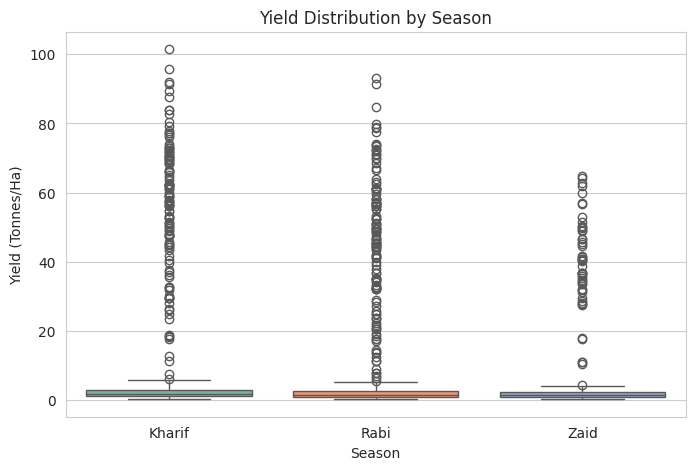

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='Set2')
plt.title('Yield Distribution by Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

The yield distribution is heavily right skewed in all three seasons the bulk of farms cluster at low yield values overall median ~1.74 t/ha while a small number of high yield outliers stretch the range up to 101.44 t/ha in Kharif, 93.13 t/ha in Rabi and 64.76 t/ha in Zaid. This suggests a small subset of farms achieve dramatically higher yields than the typical farm and that Zaid caps out at a noticeably lower maximum yield than the other two seasons. Given this skew median based comparisons are likely more reliable than mean based ones for this variable.

### 4.2 Profit Distribution by Season

/tmp/ipykernel_48884/795211404.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')


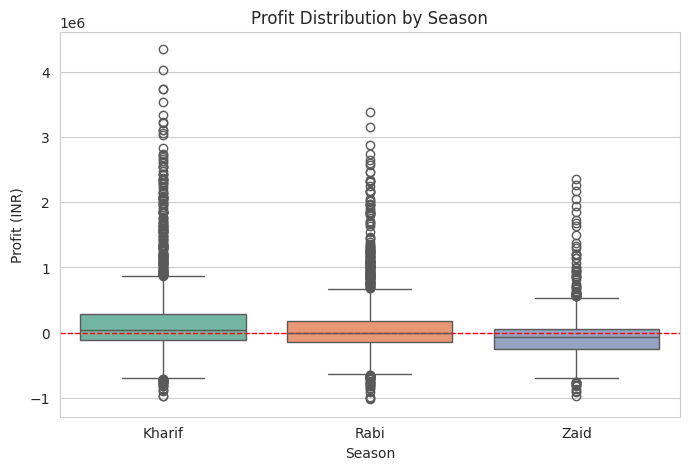

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Profit_INR', palette='Set2')
plt.title('Profit Distribution by Season')
plt.ylabel('Profit (INR)')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.show()

The boxplot confirms the pattern from Sections 3.5 and 3.10 Kharif's box sits mostly above the break even line Rabi straddles it and Zaid's box sits mostly below zero. All seasons show a long tail of high profit outliers but most farms cluster near breakeven especially in Zaid.

### 4.3 Average Rainfall and Temperature by Season

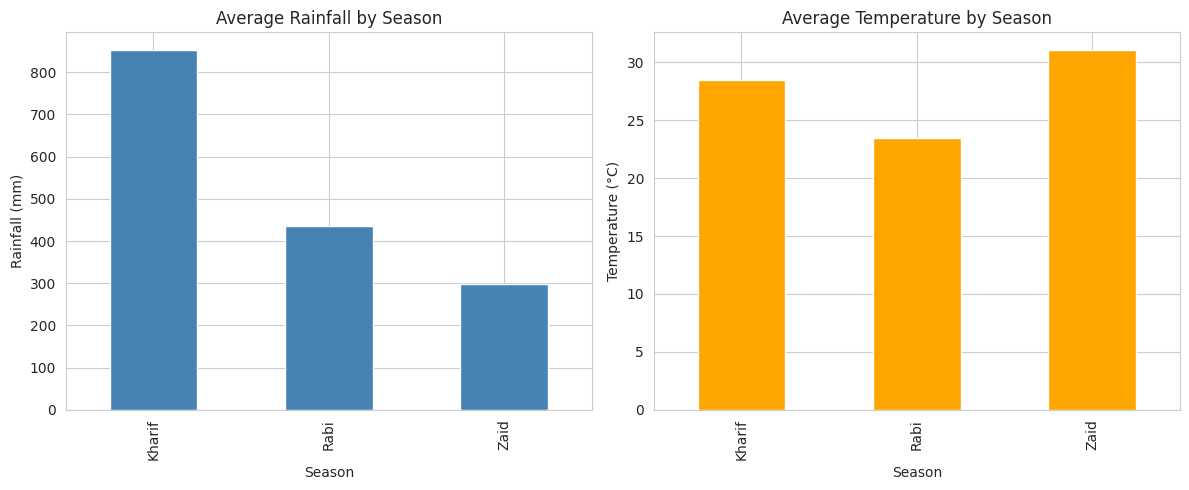

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
df.groupby('Season')['Rainfall_mm'].mean().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Rainfall by Season')
axes[0].set_ylabel('Rainfall (mm)')

df.groupby('Season')['Avg_Temperature_C'].mean().plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Average Temperature by Season')
axes[1].set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

The bar charts visually confirm Section 3.2 rainfall drops steadily from Kharif to Rabi to Zaid while temperature follows the opposite pattern dipping in Rabi before peaking in Zaid.

### 4.4 Average Water Use and Fertilizer Use by Season

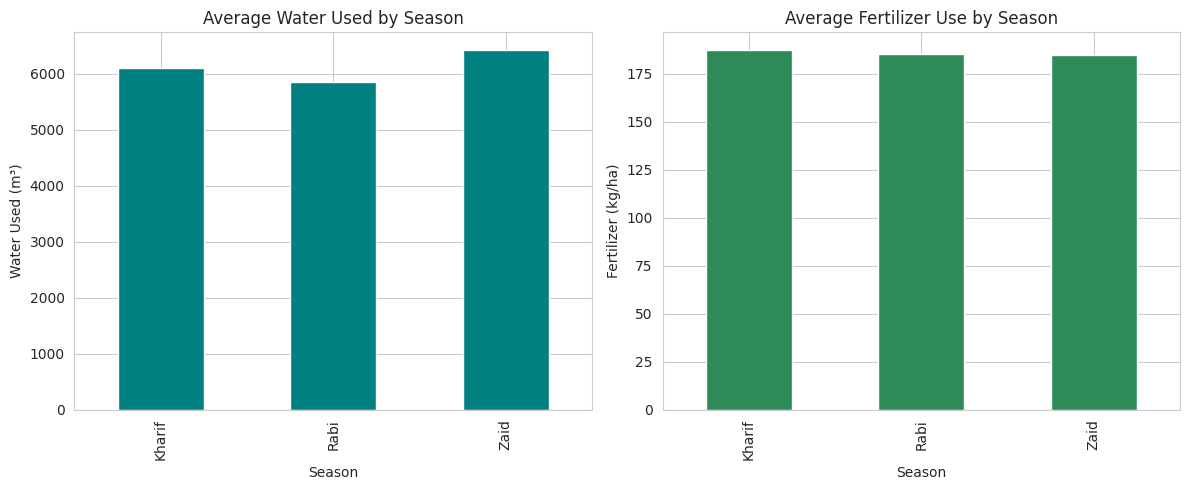

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
df.groupby('Season')['Water_Used_m3'].mean().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Average Water Used by Season')
axes[0].set_ylabel('Water Used (m³)')

df.groupby('Season')['Fertilizer_kg_ha'].mean().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Average Fertilizer Use by Season')
axes[1].set_ylabel('Fertilizer (kg/ha)')
plt.tight_layout()
plt.show()

The charts confirm Section 3.3 Zaid uses the most water despite the least rainfall while fertilizer use stays nearly flat across all seasons.

### 4.5 Correlation Heatmap of Key Variables

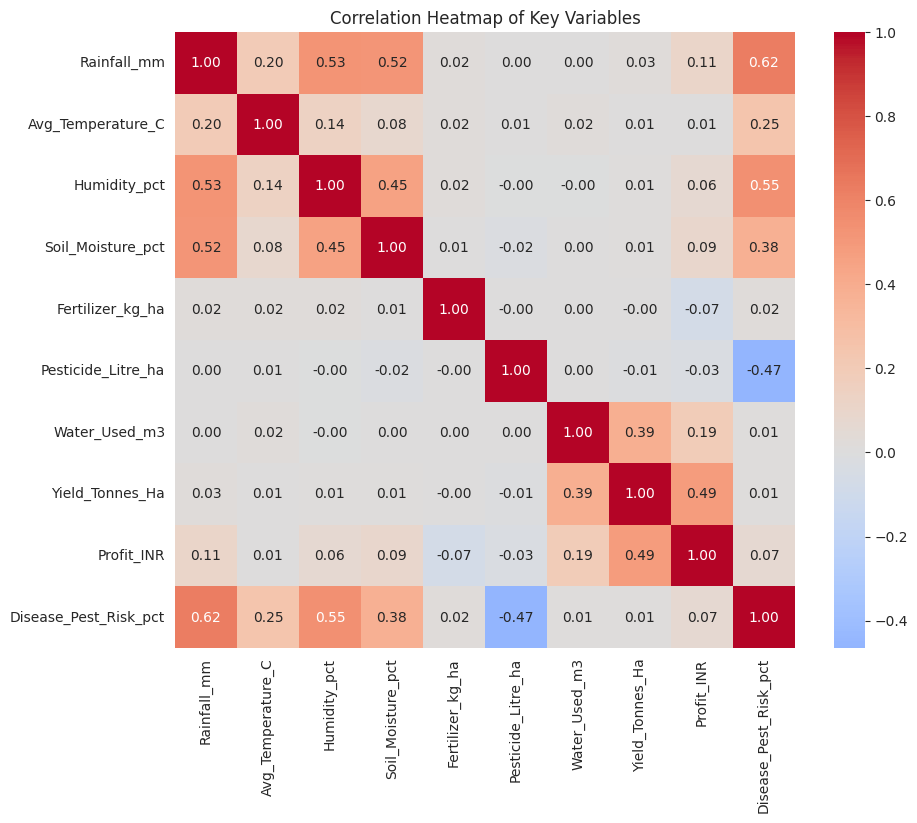

In [36]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct',
             'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3',
             'Yield_Tonnes_Ha', 'Profit_INR', 'Disease_Pest_Risk_pct']

plt.figure(figsize=(10,8))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Key Variables')
plt.show()

Yield and Profit are moderately correlated (0.49) and both are weakly correlated with Water_Used_m3 (0.39 and 0.19) more water associates with somewhat higher yield or profit but not strongly. Disease or Pest Risk correlates strongly with Rainfall (0.62) and Humidity (0.55) confirming the wet season disease pattern seen in Section 3.9 and shows a notable negative correlation with Pesticide use (-0.47) suggesting higher pesticide application is associated with lower disease or pest risk. Fertilizer use shows almost no correlation with Yield or Profit (near 0) meaning fertilizer amount alone doesn't explain performance differences.

### 4.6 Yield Heatmap by Season and Crop

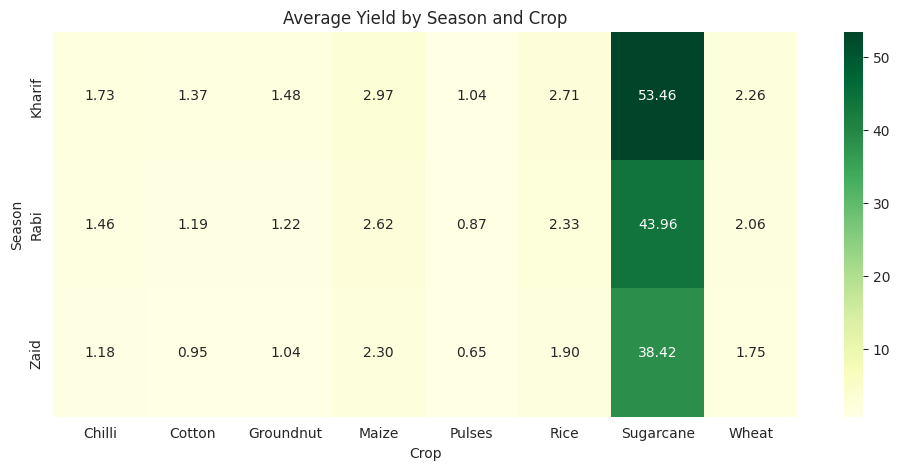

In [37]:
pivot_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().unstack()
plt.figure(figsize=(12,5))
sns.heatmap(pivot_yield, annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield by Season and Crop')
plt.show()

The heatmap visually confirms Section 3.7 Sugarcane stands out sharply from every other crop and yield decreases from Kharif to Rabi to Zaid across nearly all crops.

### 4.7 Irrigation Method Share by Season

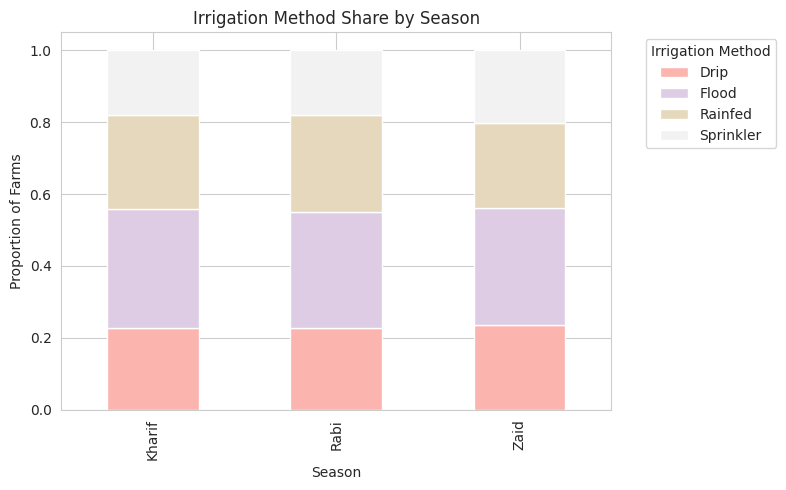

In [38]:
irr_share = pd.crosstab(df['Season'], df['Irrigation_Method'], normalize='index')
irr_share.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Pastel1')
plt.title('Irrigation Method Share by Season')
plt.ylabel('Proportion of Farms')
plt.legend(title='Irrigation Method', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

The chart confirms Section 3.8 irrigation method proportions look
nearly identical across all three seasons with no visible seasonal shift.

### 4.8 Rainfall vs Yield Relationship by Season

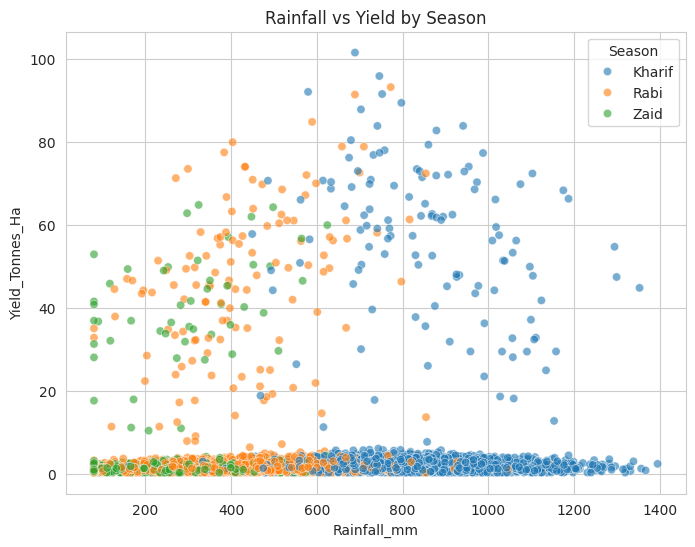

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6)
plt.title('Rainfall vs Yield by Season')
plt.show()

Points cluster into two bands rather than showing a clear trend most farms sit near zero yield regardless of rainfall while a separate high yield band (likely Sugarcane) sits well above also with no clear rainfall dependence. This matches the near zero Rainfall Yield correlation (0.03) seen in Section 4.5 rainfall alone doesn't explain yield differences here.

### 4.9 Negative Profit Rate by Season (Visualized)

/tmp/ipykernel_48884/2638741934.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  neg_rate = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean() * 100)


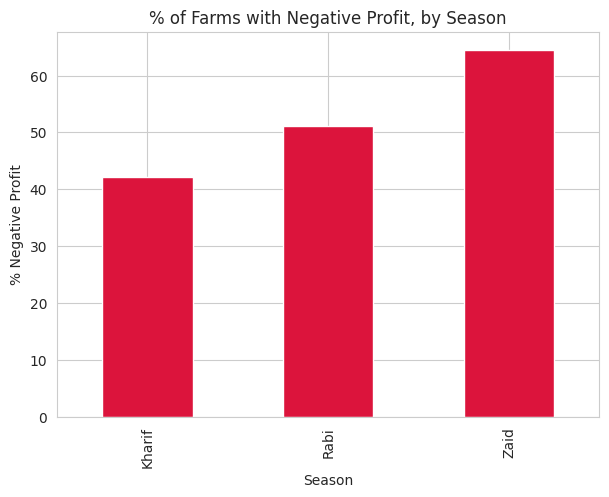

In [40]:
neg_rate = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean() * 100)
neg_rate.plot(kind='bar', color='crimson', figsize=(7,5))
plt.title('% of Farms with Negative Profit, by Season')
plt.ylabel('% Negative Profit')
plt.show()

The chart visually confirms Section 3.10 the share of loss making farms rises steadily from Kharif (42.2%) to Rabi (51.1%) to Zaid (64.5%) reinforcing Zaid as the season needing the most attention.

## 5. Statistical Testing

### 5.1 ANOVA — Yield Differences Across Seasons

In [41]:
kharif_yield = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi_yield = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid_yield = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = stats.f_oneway(kharif_yield, rabi_yield, zaid_yield)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("→ Statistically significant difference in Yield across seasons")
else:
    print("→ No statistically significant difference in Yield across seasons")

F-statistic: 1.458
P-value: 0.23285
→ No statistically significant difference in Yield across seasons


The ANOVA shows no statistically significant difference in Yield across seasons (F = 1.458, p = 0.233) despite different mean yields in Section 3.4. This is likely due to Sugarcane's extreme outlier yields inflating variance and masking the seasonal effect a limitation worth noting.

### 5.2 ANOVA — Profit Differences Across Seasons

In [42]:
kharif_profit = df[df['Season'] == 'Kharif']['Profit_INR']
rabi_profit = df[df['Season'] == 'Rabi']['Profit_INR']
zaid_profit = df[df['Season'] == 'Zaid']['Profit_INR']

f_stat, p_value = stats.f_oneway(kharif_profit, rabi_profit, zaid_profit)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("→ Statistically significant difference in Profit across seasons")
else:
    print("→ No statistically significant difference in Profit across seasons")

F-statistic: 34.292
P-value: 0.00000
→ Statistically significant difference in Profit across seasons


The ANOVA shows a statistically significant difference in Profit across seasons (F = 34.292, p < 0.00001) confirming that the profit gap seen in Sections 3.4/3.5/3.10 (Kharif profitable, Zaid running losses) is a real seasonal effect not just random variation.

### 5.3 ANOVA Summary Across Key Metrics

In [43]:
test_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Used_m3', 'Fertilizer_kg_ha', 'Disease_Pest_Risk_pct']

anova_results = []
for col in test_cols:
    groups = [df[df['Season'] == s][col] for s in df['Season'].unique()]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_results.append({'Variable': col, 'F-statistic': round(f_stat, 3), 'P-value': round(p_value, 5),
                           'Significant (p<0.05)': p_value < 0.05})

anova_df = pd.DataFrame(anova_results)
anova_df

,Variable,F-statistic,P-value,Significant (p<0.05)
0,Yield_Tonnes_Ha,1.458,0.23285,False
1,Profit_INR,34.292,0.00000,True
2,Water_Used_m3,2.467,0.08501,False
3,Fertilizer_kg_ha,0.514,0.59798,False
4,Disease_Pest_Risk_pct,1049.467,0.00000,True


Only Profit_INR and Disease_Pest_Risk_pct show statistically significant seasonal differences (p < 0.05) Yield, Water_Used, and Fertilizer do not likely due to high variance from outliers rather than a true absence of pattern.

### 5.4 Chi-Square Test — Irrigation Method vs Season

In [44]:
contingency = pd.crosstab(df['Season'], df['Irrigation_Method'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("→ Irrigation method choice is significantly associated with Season")
else:
    print("→ No significant association between Irrigation method and Season")

Chi-square statistic: 3.513
P-value: 0.74228
Degrees of freedom: 6
→ No significant association between Irrigation method and Season


The chi-square test shows no significant association between Irrigation Method and Season (χ² = 3.513, p = 0.742) confirming Section 3.8/4.7's observation that farmers don't adjust irrigation strategy based on season.

### 5.5 Chi-Square Test — Crop vs Season

In [45]:
contingency_crop = pd.crosstab(df['Season'], df['Crop'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_crop)

print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("→ Crop choice is significantly associated with Season")
else:
    print("→ No significant association between Crop and Season")

Chi-square statistic: 13.929
P-value: 0.45499
→ No significant association between Crop and Season


The chi-square test shows no significant association between Crop and Season (χ² = 13.929, p = 0.455) confirming Section 3.6's finding that crop mix stays fairly consistent across all three seasons.

### 5.6 Correlation Significance — Rainfall vs Yield

In [46]:
corr, p_value = stats.pearsonr(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])
print(f"Correlation: {corr:.3f}, P-value: {p_value:.5f}")

Correlation: 0.027, P-value: 0.08943


The correlation between Rainfall and Yield is negligible and not
statistically significant (r = 0.027, p = 0.089) confirming Section 4.8's visual finding that rainfall alone does not meaningfully explain yield differences in this dataset.

## 6. Deeper Relationships (State level, Efficiency, Anomalies)

### 6.1 Average Yield by State and Season

In [47]:
state_season_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].mean().unstack().round(2)
state_season_yield

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,5.68,3.47,4.44
Gujarat,6.34,5.67,4.07
Karnataka,6.46,4.78,6.62
Madhya Pradesh,5.99,3.76,5.46
Maharashtra,5.43,5.50,2.27
Punjab,4.10,8.61,5.91
Tamil Nadu,5.52,4.50,4.10
Telangana,5.55,4.80,4.24


Yield-by-season patterns vary meaningfully by state rather than following one uniform trend. Most states follow the overall pattern of Kharif ≥ other seasons (e.g. Andhra Pradesh, Gujarat, Madhya Pradesh, Telangana) but exceptions exist Punjab performs far better in Rabi (8.61) than Kharif (4.10) and Karnataka's best season is actually Zaid (6.62). This shows the seasonal effect isn't fully consistent across regions.

### 6.2 Yield Heatmap by State and Season

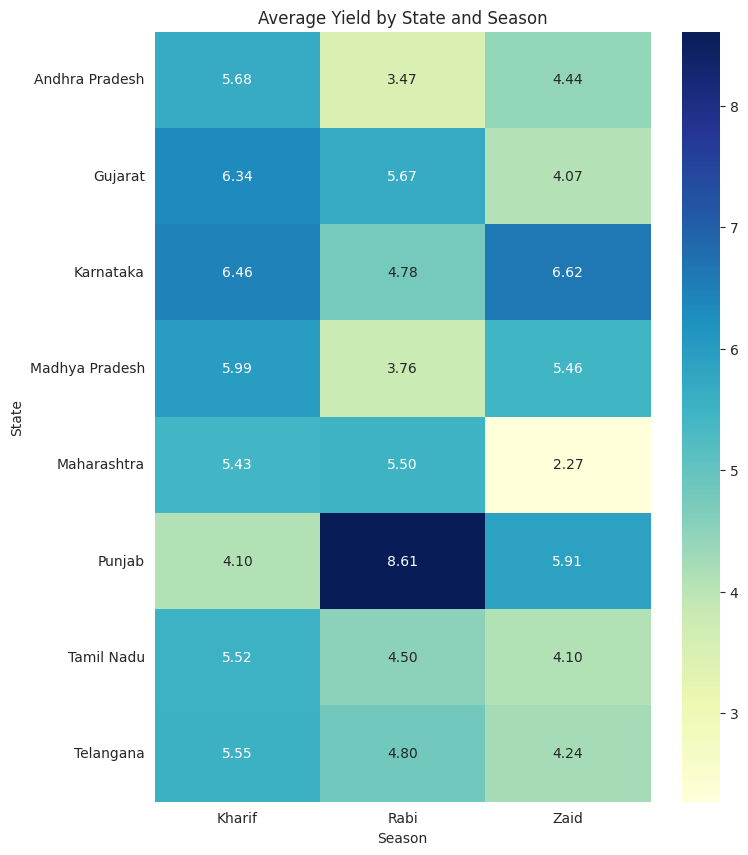

In [48]:
plt.figure(figsize=(8,10))
sns.heatmap(state_season_yield, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Average Yield by State and Season')
plt.show()

The heatmap visually confirms Section 6.1 Punjab's Rabi yield (8.61) stands out as the clear peak across the whole grid, and Maharashtra's Zaid yield (2.27) is the lowest reinforcing that these two states break from the general Kharif dominant pattern seen elsewhere.

### 6.3 Best-Performing Season by State

In [49]:
best_season_per_state = state_season_yield.idxmax(axis=1)
print(best_season_per_state)
print("\nConsistency check:")
print(best_season_per_state.value_counts())

State
Andhra Pradesh    Kharif
Gujarat           Kharif
Karnataka           Zaid
Madhya Pradesh    Kharif
Maharashtra         Rabi
Punjab              Rabi
Tamil Nadu        Kharif
Telangana         Kharif
dtype: object

Consistency check:
Kharif    5
Rabi      2
Zaid      1
Name: count, dtype: int64


Kharif is the best performing season for 5 of 8 states making it the dominant but not universal pattern like Maharashtra and Punjab perform best in Rabi and Karnataka in Zaid. So while Kharif is a reasonable default assumption for seasonal planning it shouldn't be applied uniformly these three states may benefit from season specific strategies instead.

### 6.4 Water Efficiency by State and Season

In [50]:
water_eff = df.groupby(['State', 'Season'])['Water_Efficiency_t_per_1000m3'].mean().unstack().round(2)
water_eff

Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,6.12,4.16,4.07
Gujarat,6.38,5.18,4.10
Karnataka,5.89,5.33,5.30
Madhya Pradesh,6.22,4.34,4.90
Maharashtra,5.63,5.67,3.05
Punjab,4.98,6.68,4.92
Tamil Nadu,6.07,4.95,4.13
Telangana,5.83,5.32,4.80


Water efficiency mostly follows the yield pattern from Section 6.1
Punjab is again highest in Rabi (6.68) and Maharashtra lowest in Zaid (3.05) reinforcing that these states seasonal strengths or weaknesses hold for both yield and how effectively they convert water into output.

### 6.5 Profit per Unit of Water Used by Season

In [51]:
df['Profit_per_1000m3'] = df['Profit_INR'] / (df['Water_Used_m3'] / 1000)
df.groupby('Season')['Profit_per_1000m3'].mean().round(2)

,Profit_per_1000m3
Season,
Kharif,33029.52
Rabi,12120.05
Zaid,-12032.15


Profit per unit of water follows the same downward trend seen throughout Kharif generates ₹33,029.52 profit per 1000m³ of water Rabi far less (₹12,120.05) and Zaid actually loses money per unit of water used (-₹12,032.15). This reinforces that Zaid's high water use (Section 3.3) isn't just inefficient in yield terms it's actively unprofitable.

### 6.6 Average Cost Inputs by Season

In [52]:
cost_inputs = df.groupby('Season')[['Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Water_Used_m3', 'Total_Cost_INR']].mean().round(2)
cost_inputs

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Total_Cost_INR
Season,,,,
Kharif,187.08,5.08,6102.20,531804.41
Rabi,185.41,5.02,5846.99,513836.58
Zaid,184.64,5.17,6419.89,543976.73


Total cost is highest in Zaid (₹543,976.73) despite fertilizer and pesticide use being nearly flat across seasons the extra cost is driven by Zaid's higher water use (6,419.89 m³) reinforcing that water not inputs like fertilizer is the main cost differentiator between seasons.

### 6.7 Anomaly Check — High Yield but Negative Profit

In [53]:
median_yield = df['Yield_Tonnes_Ha'].median()
anomaly = df[(df['Yield_Tonnes_Ha'] >= median_yield) & (df['Profit_INR'] < 0)]
print(f"Farms with above-median yield but negative profit: {len(anomaly)} ({len(anomaly)/len(df)*100:.1f}%)")
anomaly.groupby('Season').size()

Farms with above-median yield but negative profit: 776 (19.4%)


,0
Season,
Kharif,313
Rabi,318
Zaid,145


19.4% of all farms (776) have above-median yield but still run a loss confirming Section 6.6's finding that cost not yield is the main driver of unprofitability. This pattern appears across all seasons roughly in proportion to season size so it's not specific to any one season even farms that perform well agronomically can lose money.

### 6.8 Anomaly Check — Low Yield but Positive Profit

In [54]:
low_yield_profitable = df[(df['Yield_Tonnes_Ha'] < median_yield) & (df['Profit_INR'] > 0)]
print(f"Farms with below-median yield but positive profit: {len(low_yield_profitable)} ({len(low_yield_profitable)/len(df)*100:.1f}%)")
low_yield_profitable.groupby(['Season', 'Crop']).size().sort_values(ascending=False).head(10)

Farms with below-median yield but positive profit: 802 (20.1%)


Season  Crop     
Kharif  Pulses       129
Rabi    Cotton       109
        Pulses        95
Kharif  Cotton        92
Rabi    Groundnut     73
        Chilli        70
Kharif  Chilli        63
        Groundnut     53
Zaid    Cotton        42
        Chilli        41
dtype: int64

20.1% of farms (802) have below median yield but still turn a profit almost the mirror image of Section 6.7's finding so profit and yield are only loosely linked here and low cost crops matter more than raw output. Cotton and Pulses show up most often in this group across seasons suggesting these crops can be profitable even at modest yields likely due to lower input costs or favorable market prices.

### 6.9 Outlier Detection (IQR Method)

In [55]:
for col in ['Yield_Tonnes_Ha', 'Profit_INR']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")

Yield_Tonnes_Ha: 304 outliers (7.6%)
Profit_INR: 404 outliers (10.1%)


IQR based outlier detection flags 7.6% of farms as yield outliers and 10.1% as profit outliers consistent with the heavy right skew seen throughout Sections 3.5/4.1/4.2 mostly driven by high value Sugarcane farms and a smaller number of unusually high or low profit cases.

### 6.10 Disease or Pest Risk vs Yield by Season

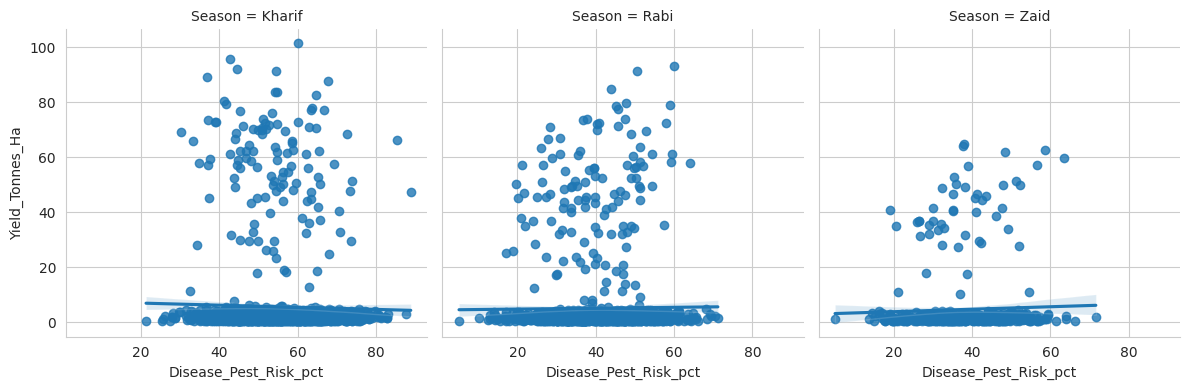

In [56]:
sns.lmplot(data=df, x='Disease_Pest_Risk_pct', y='Yield_Tonnes_Ha', col='Season', height=4, aspect=1)
plt.show()

The regression lines are nearly flat in all three seasons showing
essentially no relationship between Disease or Pest Risk and Yield once each season is viewed separately the visible high yield cluster (again likely Sugarcane) occurs across the full range of risk values rather than concentrating at low risk. This suggests disease or pest risk isn't a major direct driver of yield outcomes in this dataset.

## 7. Key Findings & Recommendations

### 7.1 Consolidated Season Level Summary

In [57]:
summary = df.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Pct_Negative_Profit=('Profit_INR', lambda x: (x < 0).mean() * 100),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2)
summary

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_t_ha,Avg_Profit_INR,Pct_Negative_Profit,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,,
Kharif,852.10,28.45,5.63,178914.65,42.21,6102.20,5.89,54.47
Rabi,435.95,23.49,5.09,87689.47,51.14,5846.99,5.19,40.48
Zaid,299.16,31.04,4.64,-24804.82,64.48,6419.89,4.41,38.22


This table consolidates the seasonal picture Kharif is wettest, highest yielding, most profitable and most water efficient but has the highest disease risk. Zaid is the opposite driest, lowest yielding, runs a net loss and has the worst water efficiency despite using the most water Rabi sits in between on most metrics.

### 7.2 Season Ranking by Metric

In [58]:
ranked = summary.rank(ascending=False)
ranked

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_t_ha,Avg_Profit_INR,Pct_Negative_Profit,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct
Season,,,,,,,,
Kharif,1.0,2.0,1.0,1.0,3.0,2.0,1.0,1.0
Rabi,2.0,3.0,2.0,2.0,2.0,3.0,2.0,2.0
Zaid,3.0,1.0,3.0,3.0,1.0,1.0,3.0,3.0


Kharif ranks best on Yield, Profit and Water Efficiency and lowest temperature adjacent metrics work in its favor too. Zaid ranks worst on Yield, Profit and Water Efficiency but ranks 1 on Pct_Negative_Profit since rank 1 here reflects the highest percentage of loss making farms not the best outcome so this column's ranking should be read in reverse when judging "best" season.

### 7.3 Summary of Statistical Significance

In [59]:
anova_df

,Variable,F-statistic,P-value,Significant (p<0.05)
0,Yield_Tonnes_Ha,1.458,0.23285,False
1,Profit_INR,34.292,0.00000,True
2,Water_Used_m3,2.467,0.08501,False
3,Fertilizer_kg_ha,0.514,0.59798,False
4,Disease_Pest_Risk_pct,1049.467,0.00000,True


### 7.4 Most Profitable Crop Season Combinations

In [60]:
top_combos = df.groupby(['Season', 'Crop'])['Profit_INR'].mean().sort_values(ascending=False).round(0)
top_combos.head(10)

Season  Crop     
Kharif  Sugarcane    1000791.0
        Chilli        954380.0
Rabi    Sugarcane     731613.0
        Chilli        638572.0
Zaid    Sugarcane     583636.0
        Chilli        448659.0
Kharif  Cotton        217000.0
        Groundnut     108265.0
Rabi    Cotton        107344.0
Kharif  Pulses         43339.0
Name: Profit_INR, dtype: float64

Sugarcane and Chilli are by far the most profitable crop season
combinations with Sugarcane in Kharif topping the list followed closely by Chilli in Kharif. Both crops remain highly
profitable across all three seasons though profit drops notably from Kharif to Zaid for each. Cotton, Groundnut and Pulses trail far behind in comparison.

### 7.5 Least Profitable Crop-Season Combinations

In [61]:
top_combos.tail(10)

Season  Crop     
Kharif  Rice         -64903.0
Zaid    Groundnut    -68872.0
Rabi    Maize        -89133.0
        Rice         -98428.0
Kharif  Wheat       -105872.0
Rabi    Wheat       -119955.0
Zaid    Pulses      -139228.0
        Wheat       -193209.0
        Maize       -194049.0
        Rice        -227239.0
Name: Profit_INR, dtype: float64

Zaid dominates the least profitable combinations Rice, Maize, Wheat and Pulses all run losses in Zaid with Zaid Rice the worst performer overall. Wheat and Rice are consistently unprofitable across multiple seasons in sharp contrast to Sugarcane and Chilli's strong performance in Section 7.4 suggesting crop choice matters far more than season alone in determining profitability.

### 7.6 Highest Risk State Season Combinations

In [62]:
risk_table = df.groupby(['State', 'Season']).apply(lambda x: (x['Profit_INR'] < 0).mean() * 100).round(1)
risk_table.sort_values(ascending=False).head(10)

/tmp/ipykernel_48884/2210865943.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  risk_table = df.groupby(['State', 'Season']).apply(lambda x: (x['Profit_INR'] < 0).mean() * 100).round(1)


,,0
State,Season,
Gujarat,Zaid,71.6
Andhra Pradesh,Zaid,70.6
Maharashtra,Zaid,68.1
Telangana,Zaid,65.9
Madhya Pradesh,Zaid,63.5
Tamil Nadu,Zaid,62.0
Karnataka,Zaid,58.1
Punjab,Zaid,55.8
Tamil Nadu,Rabi,54.3


Every single state's highest loss rate occurs in Zaid ranging from 55.8% (Punjab) to 71.6% (Gujarat) confirming Zaid's risk isn't concentrated in a few states but is a near universal pattern. Gujarat, Andhra Pradesh and Maharashtra are the highest risk state season combinations each with over two thirds of their Zaid farms running losses.

### 7.7 Key Findings
1. **Profit and disease risk differ significantly by season (statistically confirmed)**: ANOVA confirms Profit_INR (p < 0.00001) and Disease_Pest_Risk_pct (p < 0.00001) vary meaningfully across seasons while Yield, Water Use and Fertilizer do not reach statistical significance the seasonal effect on yield is masked by high variance from outlier crops like Sugarcane.

2. **Zaid is the highest-risk season consistently**: Zaid has the lowest average profit (a net loss of -₹24,804.82), the highest share of loss making farms (64.48%) and the worst water efficiency (4.41 t/1000m³) despite using the most water (6,419.89 m³). This pattern holds across every single state Zaid is each state's riskiest season from 55.8% (Punjab) to 71.6% (Gujarat) loss rates.

3. **Water, not fertilizer, drives cost differences between seasons**: Fertilizer and pesticide use are nearly flat across seasons but Zaid's higher water use directly explains its higher total cost and that water isn't converting into proportionally more yield or profit.

4. **Crop choice matters more than season**: Sugarcane and Chilli are highly profitable in every season while Rice, Wheat and Maize run losses in multiple seasons (especially Zaid). Nearly 20% of farms with below median yield are still profitable (mostly Cotton and Pulses) while another ~19% with above median yield still lose money profit is driven more by crop economics and cost than by yield alone.

5. **Irrigation strategy doesn't adapt to season**: Despite Zaid's low rainfall and poor water efficiency, irrigation method usage is nearly identical across all seasons (chi-square p = 0.742) farmers aren't shifting toward more water efficient methods when conditions call for it.

6. **Kharif is the strongest season overall, but not universally**: Kharif leads on yield, profit and water efficiency and is the best season for 5 of 8 states but Punjab and Maharashtra perform best in Rabi and Karnataka in Zaid so a one size fits all seasonal strategy would miss these exceptions.

### 7.8 Recommendations
1. **Prioritize Zaid for intervention**: Given its consistent losses across all 8 states (55.8%-71.6% of farms running deficits) Zaid should be the first target for cost reduction and efficiency programs particularly around water management.

2. **Promote water efficient irrigation in Zaid specifically**: Since irrigation method doesn't currently shift with season actively encouraging Drip or Sprinkler adoption in Zaid (where water efficiency is lowest) could reduce costs without necessarily reducing yield.

3. **Review the economics of loss making crops in Zaid**: Rice, Wheat, Maize and Pulses are unprofitable in Zaid specifically worth investigating whether these crops should be discouraged in Zaid in favor of better performing options like Sugarcane or Chilli where local conditions allow.

4. **Don't rely on yield alone as a success metric**: Since profit and yield are only moderately correlated (r = 0.49) and both above and below median yield farms show unexpected profit outcomes, planning and support programs should track cost and profit directly rather than assuming higher yield means better outcomes.

5. **Tailor recommendations by state where warranted**: While Kharif is the best default season for most states Punjab, Maharashtra and Karnataka show different optimal seasons state specific guidance would serve these three better than a blanket seasonal recommendation.

## 8. Conclusion
This analysis found that while overall yield differences across seasons were not statistically significant (masked by outlier crops like Sugarcane) profit and disease or pest risk differ significantly by season (p < 0.00001). Kharif emerged as the strongest season overall highest yield, profit and water efficiency while Zaid consistently showed the highest financial risk across every state studied, driven primarily by low water efficiency and high water cost rather than poor yield alone.
Crop choice (particularly Sugarcane and Chilli's strong performance vs. Rice and Wheat's losses) proved to be a bigger driver of profitability than season alone. These findings support prioritizing Zaid for irrigation efficiency improvements reviewing loss making crop choices in that season and using profit rather than yield as the primary metric for evaluating
seasonal agricultural planning.

### Limitations
- Missing data (~1-2% across three columns) was imputed using group wise medians rather than sourced from ground truth.
- The dataset spans only 8 states conclusions may not generalize nationally.
- Heavy skew in Yield and Profit (driven by Sugarcane outliers) limits the reliability of ANOVA results for those variables non parametric tests or outliern adjusted analysis would strengthen this further.
- Correlation findings (Section 4.5) do not imply causation.